# Faktafrågor

## 1. Vad är klustring för något? Ge några exempel på tillämpningsområden.

> Klustring är en oövervakad metod som delar in liknande observationer i grupper. Den kan till exempel användas för kundsegmentering, gruppering av låtar efter egenskaper och för att hitta avvikande beteenden.

## 2. Förklara översiktligt hur K-means fungerar. Använd figur 6.3 (sidan 238) och figur 6.4 (sidan 239) i din förklaring.

> K-means börjar med att placera ut k centroidpunkter. I figur 6.3 tilldelas varje datapunkt den närmaste centroiden. I figur 6.4 flyttas sedan varje centroid till medelvärdet för punkterna i sitt kluster. Stegen upprepas tills centroidernas positioner i stort sett slutar flytta sig.

# Resonemangsfrågor

## 3. Hur kan man välja vilket antal kluster som ska användas för en K-means modell? Använd inertia, silhouette score och silhouette diagram i ditt svar.

> Man kan testa flera värden på k. Inertia sjunker alltid när fler kluster läggs till, så man letar efter en tydlig armbåge där förbättringen planar ut. Silhouette score visar hur väl punkterna passar i sina kluster; högre är bättre. I ett silhouette-diagram vill man ha mest positiva och relativt breda staplar, utan många negativa värden.

## 4. Om du kollar på figur 6.10 på sidan 247, hur många kluster hade du valt och varför? Är det en “exakt vetenskap” att välja antalet kluster?

> Jag hade valt fyra kluster eftersom kurvan i figur 6.10 har en tydlig armbåge där. Det är inte en exakt vetenskap: resultatet beror på data, valda variabler och vad klustren ska användas till.

## 5. Hur tolkar man figur 6.13 på sidan 251?

> Figur 6.13 är ett silhouette-diagram. Varje färg visar ett kluster och varje stapel är en observation. En stapel långt åt höger betyder att observationen passar bra i sitt kluster, medan negativa värden tyder på att den kan passa bättre i ett annat kluster.

# Koduppgifter

## 7. I koden nedan använder vi datasetet “housing.csv” som användes i kapitel 2.
```python
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
df = pd.read_csv("housing.csv")
X = df.loc[:, ["median_income", "latitude", "longitude"]]
print(X.head())
kmeans = KMeans(n_clusters=6)
X["Cluster"] = kmeans.fit_predict(X)
X["Cluster"] = X["Cluster"].astype("category")
print(X.head())
sns.relplot(
x="longitude", y="latitude", hue="Cluster", data=X, height=6,
)
```

### a) Förklara vad koden gör.

> Datan läses in och tre variabler väljs ut: medianinkomst, latitud och longitud. K-means delar sedan in bostadsområdena i sex kluster. Klustret sparas i kolumnen `Cluster` och visas på en karta med olika färger.

### b) I koden har vi sex kluster (0-5). I verkligheten hade man kunnat undersöka respektive kluster för att se vilka preferenser de har, t.ex. hur de föredrar att bli kontaktade, vilka hustyper de gillar och dylikt. Om du hade lett en undersökning, vilken information hade du velat ha om respektive kluster och hur hade du designat marknadsundersökningen?

> Jag hade samlat in information om budget, hushållstyp, önskat område, bostadstyp, storlek och hur kunden vill bli kontaktad. Undersökningen hade bestått av en kort enkät, kompletterad med intervjuer med ett mindre urval från varje kluster.

### c) Det som tagits fram, hur kan det vara användbart i verkligheten för ett företag exempelvis?

> Företaget kan anpassa erbjudanden, annonser och kontaktkanaler efter respektive kluster. Det kan göra marknadsföringen mer relevant och minska kostnaden för bred reklam.

### d) Vi har gjort ett enkelt kodexempel, lek gärna runt och fortsätt utveckla det. Exempelvis kan du undersöka hur många kluster som vore bra att använda.

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

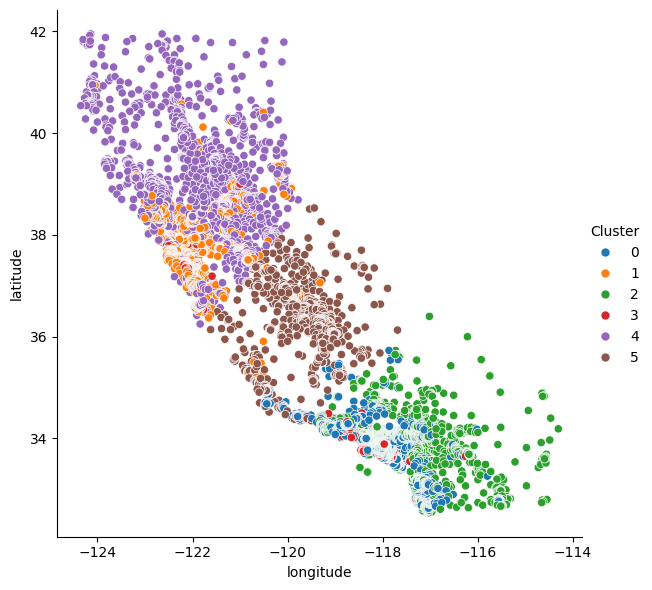

In [17]:
housing_data = pd.read_csv('../data/housing.csv')
housing_features = housing_data[['median_income', 'latitude', 'longitude']].copy()
housing_scaled = StandardScaler().fit_transform(housing_features)
housing_model = KMeans(n_clusters=6, n_init=10, random_state=1337)
housing_features['Cluster'] = pd.Categorical(housing_model.fit_predict(housing_scaled))
sns.relplot(x='longitude', y='latitude', hue='Cluster', data=housing_features, height=6)

,Clusters,Inertia,Silhouette score
0,2,26860.979326,0.548288
1,3,18986.917880,0.519595
2,4,14547.556078,0.438030
3,5,11838.587981,0.385854
4,6,10038.507422,0.397209
5,7,8732.510316,0.370926
6,8,7713.906349,0.354801
7,9,7019.713439,0.354527
8,10,6417.114181,0.340368


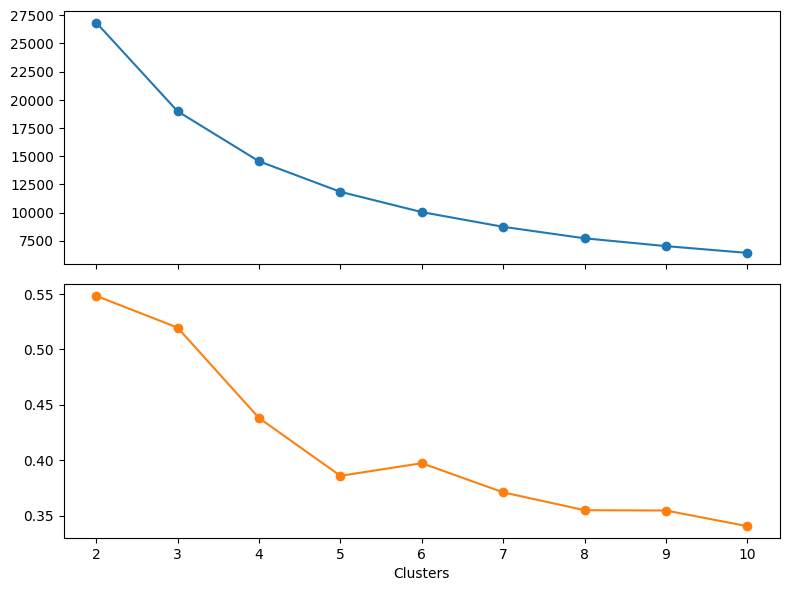

In [18]:
housing_scores = []
for cluster_count in range(2, 11):
    model = KMeans(n_clusters=cluster_count, n_init=10, random_state=1337)
    labels = model.fit_predict(housing_scaled)
    housing_scores.append([cluster_count, model.inertia_, silhouette_score(housing_scaled, labels, sample_size=5000, random_state=1337)])

housing_scores = pd.DataFrame(housing_scores, columns=['Clusters', 'Inertia', 'Silhouette score'])
display(housing_scores)
housing_scores.plot(x='Clusters', y=['Inertia', 'Silhouette score'], subplots=True, marker='o', legend=False, figsize=(8, 6))
plt.tight_layout()

### 9. Genomför en klustringanalys på datasetet som du hittar här: https://www.kaggle.com/datasets/thebumpkin/1980s-classic-hits-with-spotify-data

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [20]:
music_data = pd.read_csv('../data/1980sClassics.csv')
audio_columns = ['Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Popularity']
music_features = music_data[audio_columns].copy()
music_scaled = StandardScaler().fit_transform(music_features)
music_data[audio_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Danceability,998.0,0.626469,0.151517,0.174000,0.53400,0.633000,0.735000,0.988
Energy,998.0,0.633362,0.203787,0.018300,0.48900,0.651500,0.797000,0.994
Loudness,998.0,-8.886123,3.829896,-28.980000,-11.25600,-8.270000,-6.045000,-1.496
Speechiness,998.0,0.057630,0.055740,0.022700,0.03170,0.039350,0.056450,0.524
Acousticness,998.0,0.244627,0.248634,0.000003,0.04335,0.155000,0.387250,0.996
Instrumentalness,998.0,0.042554,0.157057,0.000000,0.00000,0.000022,0.001448,0.974
Liveness,998.0,0.178618,0.162648,0.022300,0.08395,0.113500,0.225750,0.981
Valence,998.0,0.603099,0.257874,0.028700,0.38800,0.644000,0.824750,0.984
Tempo,998.0,120.904174,26.254971,61.530000,102.30300,119.969000,135.000750,208.571
Popularity,998.0,57.743487,17.397193,0.000000,49.00000,60.000000,70.000000,96.000


,Clusters,Inertia,Silhouette score
0,2,8229.969685,0.216593
1,3,7443.561808,0.140775
2,4,6707.430942,0.169743
3,5,6103.620186,0.180581
4,6,5660.976231,0.166521
5,7,5307.416727,0.152754
6,8,5014.033156,0.147164


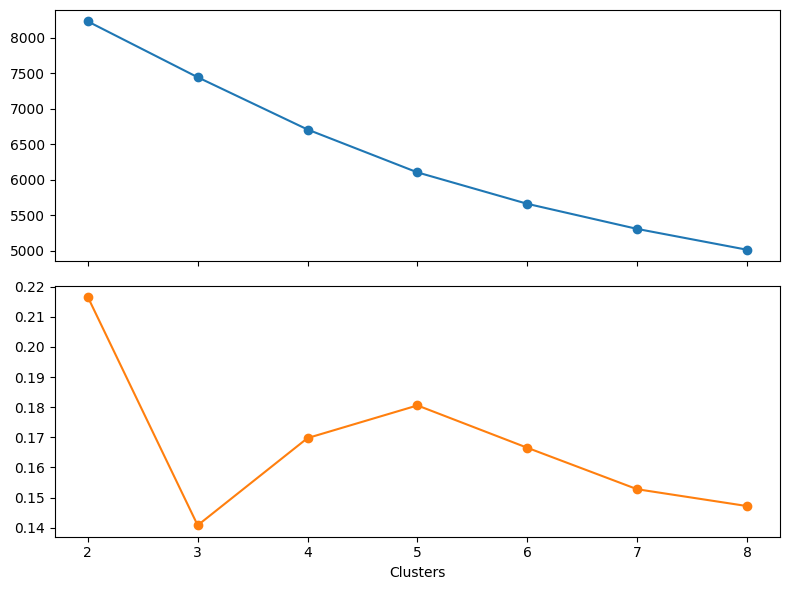

In [21]:
music_scores = []
for cluster_count in range(2, 9):
    model = KMeans(n_clusters=cluster_count, n_init=10, random_state=1337)
    labels = model.fit_predict(music_scaled)
    music_scores.append([cluster_count, model.inertia_, silhouette_score(music_scaled, labels)])

music_scores = pd.DataFrame(music_scores, columns=['Clusters', 'Inertia', 'Silhouette score'])
display(music_scores)
music_scores.plot(x='Clusters', y=['Inertia', 'Silhouette score'], subplots=True, marker='o', legend=False, figsize=(8, 6))
plt.tight_layout()

,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity
Cluster,,,,,,,,,,
0,0.530,0.409,-11.729,0.042,0.498,0.075,0.161,0.359,119.213,54.486
1,0.666,0.725,-7.722,0.064,0.141,0.029,0.186,0.703,121.597,59.078


<Axes: xlabel='Danceability', ylabel='Energy'>

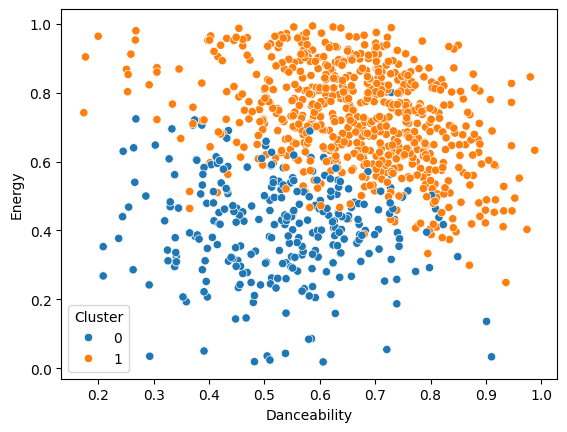

In [22]:
music_model = KMeans(n_clusters=2, n_init=10, random_state=1337)
music_data['Cluster'] = pd.Categorical(music_model.fit_predict(music_scaled))
display(music_data.groupby('Cluster', observed=False)[audio_columns].mean().round(3))
sns.scatterplot(data=music_data, x='Danceability', y='Energy', hue='Cluster')

> Två kluster gav högst silhouette score. Klustren kan användas för att beskriva två olika typer av 80-talslåtar utifrån deras ljudegenskaper.